# Day 08 — LoRA from scratch

**Why full fine-tuning is expensive, and how a low-rank adapter gets most of the benefit for
~1% of the trainable parameters — built and trained by hand in numpy.**

Yesterday you decided *to* fine-tune. Today: the mechanics. We'll train a full fine-tune and a
LoRA adapter on the same task, count every parameter and byte, sweep the rank, merge the
adapter for zero-latency inference, and show why LoRA forgets less.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | What "fine-tuning" updates, and the memory bill | 5 min |
| 1 | A tiny pretrained model + a new task | 8 min |
| 2 | Full fine-tuning: train it, count the cost | 10 min |
| 3 | LoRA: the low-rank update, from scratch | 14 min |
| 4 | Rank sweep: quality vs parameters | 8 min |
| 5 | Merge, swap, and forgetting | 10 min |
| 6 | Exercises + quiz | 5 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)
print("ready")

ready


## 0 — What fine-tuning updates, and the memory bill (5 min)

A transformer is a stack of weight matrices. **Full fine-tuning** computes a gradient for
*every* weight and updates it. The memory cost per parameter, training with Adam in fp16/fp32
mixed precision, is roughly:

| Buffer | Bytes/param |
| ------ | ----------- |
| weights (fp16) | 2 |
| gradients (fp16) | 2 |
| Adam moment `m` (fp32) | 4 |
| Adam moment `v` (fp32) | 4 |
| (often) fp32 master copy of weights | 4 |
| **total** | **~16** |

So fine-tuning a 7B model needs ~112 GB *just for optimizer state*, before activations — it
won't fit on one 80 GB GPU. **LoRA** freezes all of that and trains a tiny add-on, cutting the
trainable count (and its 16×) by 100–1000×.

In [2]:
def full_ft_memory_gb(n_params, bytes_per_param=16):
    return n_params * bytes_per_param / 1e9

for n, name in [(125e6, "GPT-2 small"), (7e9, "7B"), (70e9, "70B")]:
    print(f"{name:12s} full FT optimizer+weights ~ {full_ft_memory_gb(n):7.1f} GB")

GPT-2 small  full FT optimizer+weights ~     2.0 GB
7B           full FT optimizer+weights ~   112.0 GB
70B          full FT optimizer+weights ~  1120.0 GB


## 1 — A tiny "pretrained" model and a new task (8 min)

Our model: `y = W2 @ relu(W1 @ x)`. We'll *define* a good set of weights for **Task A** and
treat them as the frozen pretrained checkpoint. Then **Task B** differs from A by a
**deliberately low-rank** change to `W1` — this mirrors the empirical finding that the weight
*update* needed to adapt a model to a related task has low "intrinsic rank" (Hu et al., 2021).

In [3]:
D_IN, D_HID, D_OUT = 32, 64, 32

# --- the frozen "pretrained" checkpoint, good at Task A ---
W1 = rng.standard_normal((D_HID, D_IN)) / np.sqrt(D_IN)
W2 = rng.standard_normal((D_OUT, D_HID)) / np.sqrt(D_HID)

def model(x, w1, w2):
    h = np.maximum(0, x @ w1.T)
    return h @ w2.T

# --- Task A ground truth = the pretrained model itself (it's already perfect at A) ---
def task_A_target(x): return model(x, W1, W2)

# --- Task B = Task A + a rank-2 twist applied to W1 ---
TRUE_RANK = 2
U = rng.standard_normal((D_HID, TRUE_RANK)) / np.sqrt(TRUE_RANK)
V = rng.standard_normal((TRUE_RANK, D_IN)) / np.sqrt(D_IN)
DELTA_W1_TRUE = 0.8 * (U @ V)                       # the update task B "wants"
W1_B = W1 + DELTA_W1_TRUE
def task_B_target(x): return model(x, W1_B, W2)

def make_batch(n=256):
    return rng.standard_normal((n, D_IN))

def mse(pred, tgt): return float(np.mean((pred - tgt) ** 2))

Xte = make_batch(2000)
print("frozen model on Task A:", mse(model(Xte, W1, W2), task_A_target(Xte)))
print("frozen model on Task B:", round(mse(model(Xte, W1, W2), task_B_target(Xte)), 4),
      "  <- needs adaptation")
print("rank of the update Task B wants:", np.linalg.matrix_rank(DELTA_W1_TRUE))

frozen model on Task A: 0.0
frozen model on Task B: 0.3153   <- needs adaptation
rank of the update Task B wants: 2


## 2 — Full fine-tuning (10 min)

Unfreeze `W1` (keep `W2` fixed for simplicity) and train it on Task B with plain SGD. We do
the backprop by hand so nothing is hidden.

In [4]:
def train_full(steps=400, lr=0.05, seed=0):
    r = np.random.default_rng(seed)
    w1 = W1.copy()                       # start from the pretrained checkpoint
    hist = []
    for t in range(steps):
        x = r.standard_normal((256, D_IN))
        tgt = task_B_target(x)
        # forward
        z = x @ w1.T
        h = np.maximum(0, z)
        pred = h @ W2.T
        # backward (loss = mean squared error)
        g_pred = 2 * (pred - tgt) / x.shape[0]
        g_h = g_pred @ W2
        g_z = g_h * (z > 0)
        g_w1 = g_z.T @ x
        w1 -= lr * g_w1
        if t % 20 == 0:
            hist.append((t, mse(model(Xte, w1, W2), task_B_target(Xte))))
    return w1, hist

w1_full, hist_full = train_full()
trainable_full = W1.size
print(f"full FT: trainable params = {trainable_full:,}  ({W1.shape[0]}x{W1.shape[1]})")
print(f"final Task B MSE = {mse(model(Xte, w1_full, W2), task_B_target(Xte)):.5f}")
print(f"optimizer+weight memory (x16) = {trainable_full*16} bytes")

full FT: trainable params = 2,048  (64x32)
final Task B MSE = 0.00075
optimizer+weight memory (x16) = 32768 bytes


## 3 — LoRA from scratch (14 min)

**The idea.** Keep `W1` frozen. Represent the update as a product of two skinny matrices:

$$ W_1' = W_1 + \Delta W_1, \qquad \Delta W_1 = \frac{\alpha}{r}\, B A $$

- `A` is `r x D_IN`, `B` is `D_HID x r`. Only `A` and `B` are trained.
- `r` (the rank) is tiny — 1, 2, 4, 8.
- `alpha` is a fixed scaling constant.
- Init: `A` random (small), `B` **zero** — so at step 0 the adapter is a no-op and the model
  is exactly the pretrained one.

Trainable params drop from `D_HID*D_IN` to `r*(D_HID + D_IN)`.

In [5]:
def train_lora(r=2, steps=400, lr=0.05, alpha=None, seed=0):
    alpha = alpha if alpha is not None else r        # common default: alpha = r  -> scale 1.0
    scale = alpha / r
    g = np.random.default_rng(seed)
    A = g.standard_normal((r, D_IN)) * 0.01
    B = np.zeros((D_HID, r))                          # start as a no-op
    hist = []
    def eff_w1(): return W1 + scale * (B @ A)
    for t in range(steps):
        x = g.standard_normal((256, D_IN))
        tgt = task_B_target(x)
        w1e = eff_w1()
        z = x @ w1e.T
        h = np.maximum(0, z)
        pred = h @ W2.T
        # backward
        g_pred = 2 * (pred - tgt) / x.shape[0]
        g_h = g_pred @ W2
        g_z = g_h * (z > 0)
        g_w1 = g_z.T @ x                              # gradient wrt the *effective* W1
        # chain through  dW1 = scale * B @ A
        g_B = scale * (g_w1 @ A.T)
        g_A = scale * (B.T @ g_w1)
        B -= lr * g_B
        A -= lr * g_A
        if t % 20 == 0:
            hist.append((t, mse(model(Xte, eff_w1(), W2), task_B_target(Xte))))
    return A, B, scale, hist

A, B, scale, hist_lora = train_lora(r=2)
trainable_lora = A.size + B.size
print(f"LoRA r=2: trainable params = {trainable_lora:,}  (A {A.shape} + B {B.shape})")
print(f"final Task B MSE = {mse(model(Xte, W1 + scale*(B@A), W2), task_B_target(Xte)):.5f}")
print(f"reduction vs full FT: {trainable_full/trainable_lora:.1f}x fewer trainable params")

LoRA r=2: trainable params = 192  (A (2, 32) + B (64, 2))
final Task B MSE = 0.00000
reduction vs full FT: 10.7x fewer trainable params


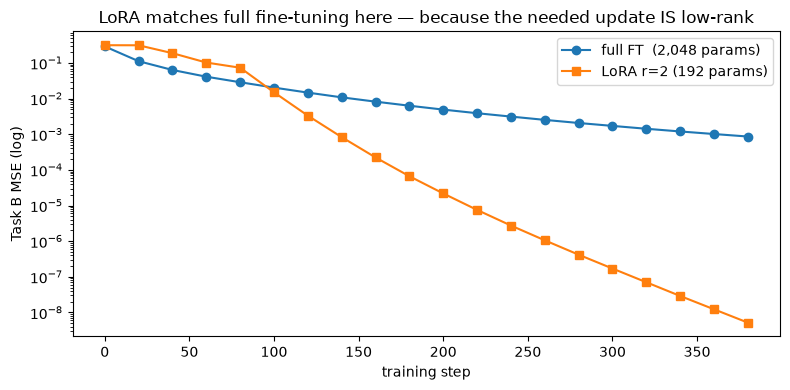

In [6]:
plt.figure(figsize=(8,4))
plt.plot(*zip(*hist_full), marker="o", label=f"full FT  ({trainable_full:,} params)")
plt.plot(*zip(*hist_lora), marker="s", label=f"LoRA r=2 ({trainable_lora:,} params)")
plt.yscale("log"); plt.xlabel("training step"); plt.ylabel("Task B MSE (log)")
plt.title("LoRA matches full fine-tuning here — because the needed update IS low-rank")
plt.legend(); plt.tight_layout(); plt.show()

In [7]:
# How close did LoRA get to the TRUE update?
dw_lora = scale * (B @ A)
print("‖ΔW_true‖      =", round(np.linalg.norm(DELTA_W1_TRUE), 3))
print("‖ΔW_lora − ΔW_true‖ =", round(np.linalg.norm(dw_lora - DELTA_W1_TRUE), 3))
print("rank(ΔW_lora)  =", np.linalg.matrix_rank(np.round(dw_lora, 6)))

‖ΔW_true‖      = 7.212
‖ΔW_lora − ΔW_true‖ = 0.001
rank(ΔW_lora)  = 32


## 4 — Rank sweep: quality vs parameters (8 min)

If the true update is rank 2, what happens with `r = 1` (too small) vs `r = 8` (bigger than
needed)?

rank   params   Task B MSE
   1       96      0.08230
   2      192      0.00000
   4      384      0.00000
   8      768      0.00000
  16    1,536      0.00000


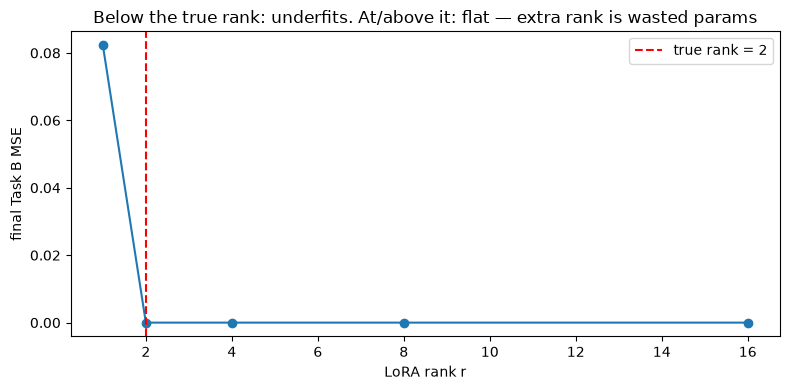

In [8]:
results = []
for r in [1, 2, 4, 8, 16]:
    A, B, scale, h = train_lora(r=r, steps=500)
    final = mse(model(Xte, W1 + scale*(B@A), W2), task_B_target(Xte))
    results.append((r, A.size + B.size, final))

print(f"{'rank':>4} {'params':>8} {'Task B MSE':>12}")
for r, p, m in results:
    print(f"{r:>4} {p:>8,} {m:>12.5f}")

rr = [x[0] for x in results]
plt.figure(figsize=(8,4))
plt.plot(rr, [x[2] for x in results], marker="o")
plt.axvline(TRUE_RANK, ls="--", color="r", label=f"true rank = {TRUE_RANK}")
plt.xlabel("LoRA rank r"); plt.ylabel("final Task B MSE"); plt.legend()
plt.title("Below the true rank: underfits. At/above it: flat — extra rank is wasted params")
plt.tight_layout(); plt.show()

- `r = 1` can't represent a rank-2 update → it plateaus higher.
- `r >= 2` all reach the same quality; `r = 8, 16` just spend more parameters for nothing.
- In practice you don't know the true rank, so people try `r in {8, 16, 32, 64}` and pick the
  smallest that clears the quality bar — exactly the "don't over-escalate" rule from Day 06.
- `alpha` and `r` interact: the effective scale is `alpha/r`, so if you double `r` you often
  double `alpha` to keep the update magnitude comparable.

## 5 — Merge, swap, and forgetting (10 min)

### Merge — LoRA adds zero inference latency

`W1' = W1 + (alpha/r) B A` can be computed once and folded into the weights. After merging,
the model is byte-identical in shape to the original — no extra matmul at inference.

In [9]:
A, B, scale, _ = train_lora(r=2, steps=500)
W1_merged = W1 + scale * (B @ A)

# unmerged path (two matmuls) vs merged path (one) -- same output
x = make_batch(4)
out_unmerged = model(x, W1, W2) + (np.maximum(0, x @ (scale*(B@A)).T) @ W2.T
                                   if False else 0)  # (relu is nonlinear; must use eff W1)
out_unmerged = model(x, W1 + scale*(B@A), W2)
out_merged   = model(x, W1_merged, W2)
print("max |unmerged - merged| =", np.abs(out_unmerged - out_merged).max(), " (numerically identical)")

max |unmerged - merged| = 0.0  (numerically identical)


In [10]:
# Swap adapters: train two different tasks, keep ONE frozen base, switch the tiny A/B pair.
DELTA_C = 0.8 * (rng.standard_normal((D_HID, 2)) / np.sqrt(2)) @ (rng.standard_normal((2, D_IN)) / np.sqrt(D_IN))
def task_C_target(x): return model(x, W1 + DELTA_C, W2)

# quick adapter for C (reuse the loop by temporarily pointing the target at C)
def train_lora_for(target_fn, r=4, steps=500, lr=0.05, seed=1):
    g = np.random.default_rng(seed); scale = 1.0
    A = g.standard_normal((r, D_IN))*0.01; B = np.zeros((D_HID, r))
    for t in range(steps):
        x = g.standard_normal((256, D_IN)); tgt = target_fn(x)
        w1e = W1 + scale*(B@A)
        z = x @ w1e.T; h = np.maximum(0, z); pred = h @ W2.T
        g_pred = 2*(pred-tgt)/x.shape[0]; g_z = (g_pred @ W2)*(z>0); g_w1 = g_z.T @ x
        B -= lr*scale*(g_w1 @ A.T); A -= lr*scale*(B.T @ g_w1)
    return A, B, scale

adapter_B = train_lora_for(task_B_target)
adapter_C = train_lora_for(task_C_target)
for name, (A,B,s), tgt in [("B", adapter_B, task_B_target), ("C", adapter_C, task_C_target)]:
    err = mse(model(Xte, W1 + s*(B@A), W2), tgt(Xte))
    size_kb = (A.nbytes + B.nbytes)/1024
    print(f"adapter {name}: MSE {err:.4f}  size {size_kb:.1f} KB  (base model shared, never copied)")

adapter B: MSE 0.0000  size 3.0 KB  (base model shared, never copied)
adapter C: MSE 0.0000  size 3.0 KB  (base model shared, never copied)


One 250 MB base model on the GPU + a few hundred KB per task. That's how a single deployment
serves dozens of fine-tunes.

### Forgetting — fewer trainable params overfit (and forget) less

Real forgetting shows up when the fine-tuning data is small and noisy: a full fine-tune has
enough free parameters to *memorise* that noise, corrupting general behaviour; LoRA's handful
of parameters physically cannot. Fine-tune both on a **small, noisy** Task-B set and measure
the gap between training fit and clean held-out error.

In [11]:
NOISE = 0.15
Xtrain_small = make_batch(48)
Ytrain_noisy = task_B_target(Xtrain_small) + NOISE * rng.standard_normal((48, D_OUT))

def train_full_fixed(steps=1500, lr=0.05):
    w1 = W1.copy()
    for _ in range(steps):
        z = Xtrain_small @ w1.T; h = np.maximum(0, z); pred = h @ W2.T
        g_w1 = ((2*(pred - Ytrain_noisy)/48 @ W2)*(z>0)).T @ Xtrain_small
        w1 -= lr * g_w1
    return w1

def train_lora_fixed(r=2, steps=1500, lr=0.05):
    A = rng.standard_normal((r, D_IN))*0.01; B = np.zeros((D_HID, r)); s = 1.0
    for _ in range(steps):
        w1e = W1 + s*(B@A); z = Xtrain_small @ w1e.T; h = np.maximum(0, z); pred = h @ W2.T
        g_w1 = ((2*(pred - Ytrain_noisy)/48 @ W2)*(z>0)).T @ Xtrain_small
        B -= lr*s*(g_w1 @ A.T); A -= lr*s*(B.T @ g_w1)
    return W1 + s*(B@A)

w1_full_f = train_full_fixed()
w1_lora_f = train_lora_fixed(r=2)
clean_te = task_B_target(Xte)

print(f"{'':12s} {'train MSE':>10} {'clean test MSE':>15}   (low train + high test = overfit)")
for name, w in [("full FT", w1_full_f), ("LoRA r=2", w1_lora_f)]:
    tr = mse(model(Xtrain_small, w, W2), Ytrain_noisy)
    te = mse(model(Xte, w, W2), clean_te)
    print(f"{name:12s} {tr:>10.4f} {te:>15.4f}")

print(f"\nfull FT can drive train MSE toward/under the noise floor ({NOISE**2:.3f}) -- it fits noise.")
print("LoRA (192 params) can't overfit 48 noisy points, so it generalises better -- the same")
print("mechanism that protects pretrained capabilities. And LoRA is reversible: drop the adapter")
print("and the base model is bit-for-bit back; full FT has no undo.")

              train MSE  clean test MSE   (low train + high test = overfit)
full FT          0.0050          0.2056
LoRA r=2         0.0193          0.0049

full FT can drive train MSE toward/under the noise floor (0.022) -- it fits noise.
LoRA (192 params) can't overfit 48 noisy points, so it generalises better -- the same
mechanism that protects pretrained capabilities. And LoRA is reversible: drop the adapter
and the base model is bit-for-bit back; full FT has no undo.


### Why LoRA is cheaper — the summary

| | Full fine-tune | LoRA |
| --- | --- | --- |
| Trainable params | all of them | `r·(d_in+d_out)` per adapted matrix, ~0.1–1% |
| Optimizer memory | 16× *all* params | 16× *only the adapter* |
| Checkpoint size | full model (GBs) | adapter only (MBs) |
| Serving many tasks | one full model each | one base + tiny adapters |
| Inference latency | baseline | baseline (merge) or +tiny (unmerged) |
| Forgetting / reversibility | higher / no | lower / yes |
| Ceiling | full capacity | limited by rank; usually enough for adaptation |

PEFT = "parameter-efficient fine-tuning", the family: LoRA, QLoRA (LoRA on a 4-bit base),
prefix/prompt tuning, adapters, IA³. LoRA/QLoRA dominate in practice.

## 6 — Exercises

1. **Param formula.** For a 7B model where you apply LoRA to `q_proj` and `v_proj` in every
   layer (each `4096 x 4096`, 32 layers), compute trainable params for `r = 8` and `r = 16`.
   Express as a % of 7B.
2. **alpha matters.** Re-run `train_lora(r=4)` with `alpha in {1, 4, 16}`. Plot the loss
   curves. What does too-small alpha do? Too-large?
3. **B-init ablation.** Change `B` initialization from zeros to small random. Does training
   still converge? What property is lost at step 0?
4. **Rank vs true rank.** Rebuild Task B with `TRUE_RANK = 5`. Re-run the rank sweep. Does the
   elbow move to r=5?
5. **QLoRA sketch.** Quantize the frozen `W1` to int8 (`np.round(W1/scale_q)*scale_q`) before
   training a LoRA adapter on top. How much does final MSE change? (This is the core QLoRA
   trick: 4-bit base + fp16 adapter.)
6. **Serving math.** You have a 13B base (26 GB fp16) and 40 customer-specific LoRA adapters
   (r=16 on q/v, 40 layers, `5120x5120`). Total GPU memory for base + all adapters?

> **Attempt every exercise and the quiz first.** The worked solutions and the answer key live in [`solutions/solutions.ipynb`](solutions/solutions.ipynb) — open it only to check your work, not to start.

## Self-check quiz


1. Roughly how many bytes per parameter does full fine-tuning with Adam need, and why so many?
2. Write the LoRA update equation and say which matrices are trained.
3. Why is `B` initialized to zero?
4. Your true task-update is rank ~4. You use LoRA `r = 1`. What symptom do you see?
5. Does a merged LoRA adapter add inference latency? An unmerged one?
6. Give two reasons LoRA "forgets" the base task less than full fine-tuning.
7. What does QLoRA change relative to plain LoRA, and what does it buy?

## Where this goes next

- **Day 09 — LoRA on Hugging Face:** run the real thing — `peft` + `transformers` on a small
  open model on a free Colab GPU — and see the same knobs (`r`, `alpha`, target modules) in a
  production library. Includes a pure-numpy fallback that runs here with no GPU.